In [1389]:
import numpy as np
import torch 
import itertools
import pandas as pd
import matplotlib.pyplot as plt
from anastruct import SystemElements
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt 
import openpyxl as pxl
import torch.nn.functional as F
import os
import re
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics  import mean_absolute_error, r2_score


In [1390]:
#General Parameters for improve results
"""
K = 5

"""

'\nK = 5\n\n'

In [1391]:
#import Excel Data

notebook_dir = os.getcwd()
file_path =os.path.join(notebook_dir,'Data','MLPARTA.xlsx')

In [1392]:
#read Excel with formulas using Openpyxl

wb = pxl.load_workbook(file_path)
ws = wb.active 

headers = [ws.cell(1,col).value for col in range (1,ws.max_column+1)]

#Convert excel language to python


letter_to_name = {}
for col in range(1,ws.max_column+1):
    letter = pxl.utils.get_column_letter(col)
    letter_to_name[letter] =headers[col-1]

def excel_to_python(formula, letter_to_name):
    result = formula
    result = result.lstrip('=')
    result = result.replace('$', '')
    result = re.sub(r'\bPI\(\)', 'np.pi', result)

    def replace_ref(match):
        letter = match.group(1)
        if letter in letter_to_name:
            name = letter_to_name[letter]
            return f"df['{name}']"
        return match.group(0)

    result = re.sub(r'\b([A-Z]{1,3})(\d+)\b', replace_ref, result)
    
    excel_to_np = {
        'SIN'   : 'np.sin',
        'COS'   : 'np.cos',
        'TAN'   : 'np.tan',
        'ATAN'  : 'np.arctan',
        'ATAN2' : 'np.arctan2',
        'ASIN'  : 'np.arcsin',
        'ACOS'  : 'np.arccos',
        'SQRT'  : 'np.sqrt',
        'ABS'   : 'np.abs',
        'EXP'   : 'np.exp',
        'LOG'   : 'np.log',
        'LOG10' : 'np.log10',
        'POWER' : 'np.power',
        'MOD'   : 'np.mod',
        'FLOOR' : 'np.floor',
        'CEIL'  : 'np.ceil',
        'ROUND' : 'np.round',
        'MAX'   : 'np.maximum',
        'MIN'   : 'np.minimum',
        'SUM'   : 'np.sum',
    }

    for excel_fn, np_fn in excel_to_np.items():
        result = re.sub(rf'\b{excel_fn}\b', np_fn, result)

    result = result.replace('^', '**')
    result = result.lstrip('=')

    return result


# Find Formula
formula_list = {}
for col in range(1,ws.max_column+1):
    cell =ws.cell(2,col)
    value = cell.value
    name = headers[col-1]
    if isinstance(value,str) and value.startswith('='):
        formula_list[name]=excel_to_python(value,letter_to_name)

raw_cols = [h for h in headers if h not in formula_list]

def compute_features(df,formula_list):
    df = df.copy()
    remaining = dict(formula_list)
    max_passes = len(formula_list)+1
    passes =0 

    while remaining and passes < max_passes:
        passes +=1
        newly_computed=[]
        
        for col_name, expr in remaining.items():
            try:
                df[col_name]=eval(expr)
                newly_computed.append(col_name)
            except Exception:
                pass
        for col in newly_computed:
            del remaining[col]
        if not newly_computed:
            print(f"\n Warning Error Newly Computed")
            break
    return df

wb_data = pxl.load_workbook(file_path, data_only=True)
ws_data = wb_data.active
data    = [row for row in ws_data.iter_rows(min_row=2, values_only=True)]
df_raw  = pd.DataFrame(data, columns=headers)
df_computed = compute_features(df_raw[raw_cols], formula_list)
df_training = df_computed.drop(columns=[None], errors='ignore').dropna().reset_index(drop=True)
print(f"df_training shape: {df_training.shape}")   # should be (100, 28)


df_training shape: (100, 28)


In [1393]:
# # Verify 
# # ── 8. Verify against Excel ───────────────────────────────────
# print(f"\n{'='*60}")
# print(f"  Verify — Python vs Excel (row 1)")
# print(f"{'='*60}")
# print(f"{'Column':>15} | {'Excel':>12} | {'Python':>12} | {'Match':>6}")
# print(f"{'-'*60}")

# match_count = 0
# for col in formula_list.keys():
#     if col in df_raw.columns and col in df_computed.columns:
#         excel_val  = df_raw[col].iloc[0]
#         python_val = df_computed[col].iloc[0]
#         if excel_val is not None and not pd.isna(excel_val):
#             match = abs(excel_val - python_val) < 1e-4
#             if match:
#                 match_count += 1
#             print(f"{col:>15} | {excel_val:>12.4f} | {python_val:>12.4f} | "
#                   f"{'✓' if match else '✗':>6}")

# print(f"\n  Matched : {match_count} / {len(formula_list)} columns")
# print(f"{'='*60}")

# # ── 9. Final dataset summary ──────────────────────────────────
# print(f"\n{'='*60}")
# print(f"  FINAL DATASET")
# print(f"{'='*60}")
# print(f"  Shape   : {df_computed.shape}")
# print(f"  Columns : {df_computed.columns.tolist()}")
# print(f"\n{'='*60}")
# print(f"  STATISTICS")
# print(f"{'='*60}")
# print(f"{'Column':>15} | {'Min':>12} | {'Max':>12} | {'Mean':>12}")
# print(f"{'-'*60}")
# for col in df_computed.columns:
#     vals = df_computed[col].dropna()
#     if vals.dtype in [float, int]:
#         print(f"{col:>15} | {vals.min():>12.4f} | "
#               f"{vals.max():>12.4f} | {vals.mean():>12.4f}")
# print(f"{'='*60}")

In [1394]:
# # Print formulas 
# print(f"  Formula — {len(formula_list)} columns")
# for col_name, expr in formula_list.items():
#     print(f"\n  Column  : {col_name}")
#     print(f"  Python  : {expr}")


In [1395]:
def is_constant(series, cv_threshold=0.01):
    std  = series.std()
    mean = series.mean()
    if pd.isna(std) or std == 0:    return True
    if mean == 0 or pd.isna(mean):  return std < 1e-10
    return (std / abs(mean)) < cv_threshold



constant_cols = {}
target_col    = 'Power'

for col in df_training.columns:
    if col is None:
        continue
    if col == target_col:
        continue
    series = df_training[col].dropna()   # guard against empty columns
    if len(series) == 0:
        continue
    if is_constant(series):
        constant_cols[col] = series.iloc[0]

C = df_training[list(constant_cols.keys())].copy()
Y = df_training[[target_col]].copy()
X = df_training.drop(
        columns=list(constant_cols.keys()) + [target_col],
        errors='ignore'
    ).copy()
X = X[[col for col in X.columns if col is not None]]

feature_cols = list(X.columns)   # needed by PINN cell

x = torch.tensor(X.values, dtype=torch.float32)
y = torch.tensor(Y.values, dtype=torch.float32).squeeze(1)
c = torch.tensor(C.values, dtype=torch.float32)

print(f"  Dataframe check ")

print(f"\n  C — Constants : {C.shape}")
print(f"    {C.columns.tolist()}")
print(f"\n  Y — Target    : {Y.shape}")
print(f"    {Y.columns.tolist()}")
print(f"\n  X — Features  : {X.shape}")
print(f"    {X.columns.tolist()}")

print(f"  x tensor : {x.shape}")
print(f"  y tensor : {y.shape}")
print(f"  c tensor : {c.shape}")
print(f"  NaN in x : {torch.isnan(x).sum().item()}")
print(f"  NaN in y : {torch.isnan(y).sum().item()}")
print(f"  NaN in c : {torch.isnan(c).sum().item()}")


  Dataframe check 

  C — Constants : (100, 5)
    ['F_PB', 'Density', 'W_motor', 'Fx_s', 'Ftotal_s']

  Y — Target    : (100, 1)
    ['Power']

  X — Features  : (100, 22)
    ['R', 'L', 'offset_e', 'cross_area', 'ac_rad', 'm_crank', 'm_link', 'm_tot', 'm_slid', 'slider_y', 'a_cl', 's_omega', 's_alpha', 's_inertia', 'F_cl', 'Fx_cl', 'Fy_cl', 'Ftan_c', 'c_inertia', 'Torque', 'Beta', 'QRR']
  x tensor : torch.Size([100, 22])
  y tensor : torch.Size([100])
  c tensor : torch.Size([100, 5])
  NaN in x : 0
  NaN in y : 0
  NaN in c : 0


In [1396]:
#Parameters

batch_size=16#to be modified 
num_workers=0#cpu
seed  =42 #shuffle

class Training(Dataset):

    def __init__(self, x_mix, y_mix, x_orig):
        assert x_mix.shape[0] == y_mix.shape[0] == x_orig.shape[0], (
            f"Size mismatch: x_mix={x_mix.shape[0]}, y_mix={y_mix.shape[0]}, "
            f"x_orig={x_orig.shape[0]}"
        )
        self.x_mix  = x_mix
        self.y_mix  = y_mix
        self.x_orig = x_orig

    def __len__(self):
        return self.x_mix.shape[0]

    def __getitem__(self, idx):
        return (
            self.x_mix[idx],
            self.y_mix[idx],
            self.x_orig[idx],
        )

    @property
    def n_features(self):
        return self.x_mix.shape[1]

    def __repr__(self):
        return f"Training(n={len(self)}, features={self.n_features})"

class Validation(Dataset):

    def __init__(self,x,y,c):
        assert x.shape[0] == y.shape[0] == c.shape[0], (
            f"Size mismatch: x={x.shape[0]}, y={y.shape[0]}, c={c.shape[0]}"
        ) #error check. Stops before
        self.x = x
        self.y = y
        self.c = c

    def __len__(self):
        return self.x.shape[0]

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx], self.c[idx]

    @property
    def n_features(self):
        return self.x.shape[1]

    @property
    def n_constants(self):
        return self.c.shape[1]

    def __repr__(self):
        return (
            f"Validation(n={len(self)}, "
            f"features={self.n_features}, "
            f"constants={self.n_constants})"
        )


def get_dataloaders(train_ds,val_ds,batch_size,num_workers,seed) -> tuple[DataLoader, DataLoader]:

    g = torch.Generator().manual_seed(seed) #shuffle 

    train_loader = DataLoader(
        train_ds,
        batch_size  = batch_size,
        shuffle     = True,
        drop_last   = True,
        num_workers = num_workers,
        generator   = g, #shuffle
    )
    val_loader = DataLoader(
        val_ds,
        batch_size  = batch_size,
        shuffle     = False,
        drop_last   = False,
        num_workers = num_workers,
    )
    return train_loader, val_loader


In [1397]:
#Stratified K-Fold => For cross validation after

def skfold_idx(y, K, seed=42):
    torch.manual_seed(seed)
    sorted_idx  = torch.argsort(y)
    fold_assign = torch.zeros(len(y), dtype=torch.long)
    for rank, idx in enumerate(sorted_idx):
        fold_assign[idx] = rank % K
    fold_indices = []
    for k in range(K):
        val_idx   = (fold_assign == k).nonzero(as_tuple=True)[0]
        train_idx = (fold_assign != k).nonzero(as_tuple=True)[0]
        fold_indices.append((train_idx, val_idx))
    return fold_indices

def mixup(x,y,c,alpha=0.4,seed=42):
    np.random.seed(seed)
    N = x.size(0)

    lam   = np.random.beta(alpha, alpha, size=N)
    lam   = np.maximum(lam, 1 - lam)
    lam_t = torch.tensor(lam, dtype=torch.float32)
    lam_x = lam_t.unsqueeze(1)

    idx   = torch.randperm(N)

    x_mix = lam_x * x + (1 - lam_x) * x[idx]
    y_mix = lam_t * y + (1 - lam_t) * y[idx]
    c_mix = lam_x * c + (1 - lam_x) * c[idx]

    return x_mix, y_mix, c_mix

K            = 5
fold_indices = skfold_idx(y, K, seed=42)

In [1398]:
class Power(nn.Module):
    def __init__(self, input_dim, dropout=0.2):
        super().__init__()

        self.block1 = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.BatchNorm1d(32),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        self.block2 = nn.Sequential(
            nn.Linear(32, 64),
            nn.BatchNorm1d(64),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        self.block3 = nn.Sequential(
            nn.Linear(64, 128),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        self.block4 = nn.Sequential(
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        self.skip_act = nn.GELU()
        self.block5 = nn.Sequential(
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        self.head = nn.Linear(32, 1)
     

    def forward(self, x):
        x   = self.block1(x)
        x   = self.block2(x)
        res = x
        x   = self.block3(x)
        x   = self.block4(x)
        x   = self.skip_act(x + res)
        x   = self.block5(x)
        return self.head(x).squeeze(1)

In [1399]:
## === PHYSICS NOTES TO READ == ##

# Mean Squared Error & a low lambda 

# We will use the physics as our ground truth => which will be use to compute loss, and then this loss
#then the loss is used as the reward (punishing/award of good data)
# Necessary since we have low dataset
""""
R, L, offset_e, cross_area, ac_rad
        ↓
m_crank = cross_area × R × Density
m_link  = L × cross_area × Density
m_tot   = m_crank + m_link
m_slid  = 0.2 × m_tot
        ↓
slider_y = R×sin(ac_rad) + sqrt(L² - (R×cos(ac_rad) - offset_e)²)
a_cl     = arctan(slider_y + offset_e - R×sin(ac_rad))
        ↓
s_omega  = R×W_motor×cos(ac_rad) + ...
s_alpha  = ...
        ↓
s_inertia = m_slid × s_alpha
Fx_s      = F_cl × cos(a_cl)
Ftotal_s  = Fx_s + s_inertia
        ↓
F_cl    = (s_inertia + F_PB) / cos(a_cl)
Ftan_c  = F_cl × sin(ac_rad + a_cl)
        ↓
Torque  = Ftan_c × R
Power   = Torque × W_motor

Candidates: 
1.  F_cl    = (s_inertia + F_PB) / cos(a_cl)       force on connecting link
2.  Ftan_c  = F_cl × sin(ac_rad + a_cl)            tangential crank force  
3.  Torque  = Ftan_c × R                            output torque
4.  Power   = Torque × W_motor                      final target
5.  m_tot   = m_crank + m_link                      total mass
6.  s_omega = R×W_motor×cos(ac_rad) + ...           slider velocity

"""

# The choice can be modified
#Chosen formulas:
""""
loss_1 = MSE(F_CL)
loss_2 = MSE(Torque)
loss_3 = MSE(Power)

"""

'"\nloss_1 = MSE(F_CL)\nloss_2 = MSE(Torque)\nloss_3 = MSE(Power)\n\n'

In [1400]:
def get_constant(name):
    if name not in constant_cols:
        raise KeyError(f"'{name}' not found")
    return constant_cols[name]

CHECK = ['F_cl', 'Torque', 'Power']

missing = [p for p in CHECK if p not in formula_list]
if missing:
    raise ValueError(f"CHECK missing from formula_list: {missing}")

def to_torch_expr(expr):
    return expr.replace('np.', 'torch.')

exprs = {
    name: to_torch_expr(formula_list[name])
    for name in CHECK
}

constant_needed = [
    name for name in constant_cols
    if any(f"df['{name}']" in expr for expr in exprs.values())
]

feat_cols = list(dict.fromkeys(
    match
    for expr in exprs.values()
    for match in re.findall(r"df\['(\w+)'\]", expr)
    if match in feature_cols
))

F_idx = {col: feature_cols.index(col) for col in feat_cols}  

LAMBDA = 0.4


def physics_loss(pred_norm, x_orig, x_mean, x_std, y_mean, y_std):
    df = {}

    for col, idx in F_idx.items():
        df[col] = x_orig[:, idx] * x_std[idx] + x_mean[idx]
    for name in CHECK:
        if name in feature_cols and name not in df:
            idx = feature_cols.index(name)
            df[name] = x_orig[:, idx] * x_std[idx] + x_mean[idx]

    for name in constant_needed:
        df[name] = get_constant(name)

    pred_watts = pred_norm * y_std + y_mean

    Loss_1     = eval(exprs['F_cl'])           
    Loss_1_mse = F.mse_loss(df['F_cl'], Loss_1)

    Loss_2     = eval(exprs['Torque'])          
    Loss_2_mse = F.mse_loss(df['Torque'], Loss_2)

    Loss_3     = Loss_2 * df['W_motor']         
    Loss_3_mse = F.mse_loss(pred_watts, Loss_3)

    return LAMBDA * (Loss_1_mse + Loss_2_mse + Loss_3_mse)  

In [1401]:
# Helper Functions 

def train_epoch(model, loader, optimizer, device, x_mean, x_std, y_mean, y_std):
    model.train()
    criterion  = nn.MSELoss()
    total_loss = 0.0

    for x_mix, y_mix, x_orig in loader:
        x_mix  = x_mix.to(device)
        y_mix  = y_mix.to(device)
        x_orig = x_orig.to(device)

        optimizer.zero_grad()

        pred = model(x_mix)

        loss_data    = criterion(pred, y_mix)
        loss_physics = physics_loss(
            pred, x_orig,
            x_mean.to(device), x_std.to(device),
            y_mean.to(device), y_std.to(device),
        )
        loss = loss_data + loss_physics  

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item() * len(x_mix)

    return total_loss / len(loader.dataset)

@torch.no_grad()
def evaluate(model, loader, device):

    model.eval()
    criterion  = nn.MSELoss()
    total_loss = 0.0
    all_preds, all_actuals = [], []

    for x_batch, y_batch, _ in loader:  
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        pred = model(x_batch)
        loss = criterion(pred, y_batch)

        total_loss += loss.item() * len(x_batch)
        all_preds.append(pred.cpu())
        all_actuals.append(y_batch.cpu())

    return (
        total_loss / len(loader.dataset),
        torch.cat(all_preds),
        torch.cat(all_actuals),
    )
def tester(y_pred_norm, y_true_norm, y_mean, y_std):

    # Denormalize → Watts
    y_pred = (y_pred_norm * y_std + y_mean).numpy()
    y_true = (y_true_norm * y_std + y_mean).numpy()

    mae    = np.mean(np.abs(y_pred - y_true))
    rmse   = np.sqrt(np.mean((y_pred - y_true) ** 2))
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    r2     = 1 - ss_res / (ss_tot + 1e-8)

    return mae, rmse, r2


In [1402]:
# PARAMETERS
epochs = 500
patience =50
batch_size=16

device = torch.device(
    'mps'  if torch.backends.mps.is_available()  else
    'cuda' if torch.cuda.is_available()          else
    'cpu'
) # AI recommended 




In [1403]:
# K Loops

fold_mae_list  = []
fold_rmse_list = []
fold_r2_list   = []
all_preds_global   = []  
all_actuals_global = []  

best_fold_mae   = float('inf')
best_fold_state = None
best_fold_stats = {}

for fold, (train_idx, val_idx) in enumerate(fold_indices):

    # Data Split
    x_tr  = x[train_idx]
    y_tr  = y[train_idx]
    x_val = x[val_idx]
    y_val = y[val_idx]
    c_val = c[val_idx]

    # Normalize
    x_mean = x_tr.mean(dim=0)
    x_std  = x_tr.std(dim=0).clamp(min=1e-8)
    y_mean = y_tr.mean()
    y_std  = y_tr.std()

    x_tr_norm  = (x_tr  - x_mean) / x_std
    x_val_norm = (x_val - x_mean) / x_std
    y_tr_norm  = (y_tr  - y_mean) / y_std
    y_val_norm = (y_val - y_mean) / y_std

    # Mixup
    x_mix, y_mix, _ = mixup(x_tr_norm, y_tr_norm, c[train_idx], alpha=0.2, seed=42+fold)

    # Datasets
    train_ds = Training(x_mix, y_mix, x_tr_norm)
    val_ds   = Validation(x_val_norm, y_val_norm, c_val)
    train_loader, val_loader = get_dataloaders(
        train_ds, val_ds, batch_size=batch_size, num_workers=0, seed=40+fold,
    )

    # Model
    model     = Power(input_dim=x.shape[1]).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=5e-2)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=30, min_lr=1e-6
    )

    # Training Loop
    best_val_loss     = float('inf')
    best_state        = None
    epochs_no_improve = 0
    stopped_epoch     = epochs

    for epoch in range(1, epochs + 1):
        train_epoch(model, train_loader, optimizer, device, x_mean, x_std, y_mean, y_std)
        val_loss, _, _ = evaluate(model, val_loader, device)
        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss     = val_loss
            best_state        = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            stopped_epoch = epoch
            break

    # Evaluate
    model.load_state_dict(best_state)
    _, y_pred_norm, y_true_norm = evaluate(model, val_loader, device)

    mae, rmse, r2 = tester(y_pred_norm, y_true_norm, y_mean, y_std)

    
    y_pred_w = (y_pred_norm * y_std + y_mean).numpy()
    y_true_w = (y_true_norm * y_std + y_mean).numpy()
    all_preds_global.append(y_pred_w)
    all_actuals_global.append(y_true_w)

    fold_mae_list.append(mae)
    fold_rmse_list.append(rmse)
    fold_r2_list.append(r2)

    print(f"  {fold+1:>5} | {mae:>10.4f} | {rmse:>10.4f} | "
          f"{r2:>8.4f} | {stopped_epoch:>7}")

    # Track best fold
    if mae < best_fold_mae:
        best_fold_mae   = mae
        best_fold_state = {k: v.clone() for k, v in model.state_dict().items()}
        best_fold_stats = {
            'x_mean' : x_mean.clone(),
            'x_std'  : x_std.clone(),
            'y_mean' : y_mean.clone(),
            'y_std'  : y_std.clone(),
        }

      1 |     1.6670 |     2.0970 |   0.9846 |     189
      2 |     2.6146 |     3.2221 |   0.9629 |     116
      3 |     1.9865 |     2.4303 |   0.9787 |      85
      4 |     2.3494 |     2.9571 |   0.9683 |     105
      5 |     1.8448 |     2.4231 |   0.9795 |     154


  Step 5.5 — Validation Report
   Fold |    MAE (W) |   RMSE (W) |       R² |     Status
  -------------------------------------------------------
      1 |     1.6670 |     2.0970 |   0.9846 |       ✓ ok
      2 |     2.6146 |     3.2221 |   0.9629 | ⚠ unstable
      3 |     1.9865 |     2.4303 |   0.9787 |       ✓ ok
      4 |     2.3494 |     2.9571 |   0.9683 |       ✓ ok
      5 |     1.8448 |     2.4231 |   0.9795 |       ✓ ok

  ───────────────────────────────────────────────────────
   Mean |     2.0925 |     2.6259 |   0.9748
    Std |     0.3442 |     0.4060 |   0.0080
    Min |     1.6670 |     2.0970 |   0.9629
    Max |     2.6146 |     3.2221 |   0.9846

  Consistency Check
  ----------------------------------------
  MAE CV : 0.164  ⚠ moderate variance — check unstable folds
  R² min : 0.9629  ✓ all folds above 0.95

  Residual Analysis (best fold)
  ----------------------------------------
  Residual mean  :   0.4195 W  (close to 0 = unbiased)
  Residual std   :   2.054

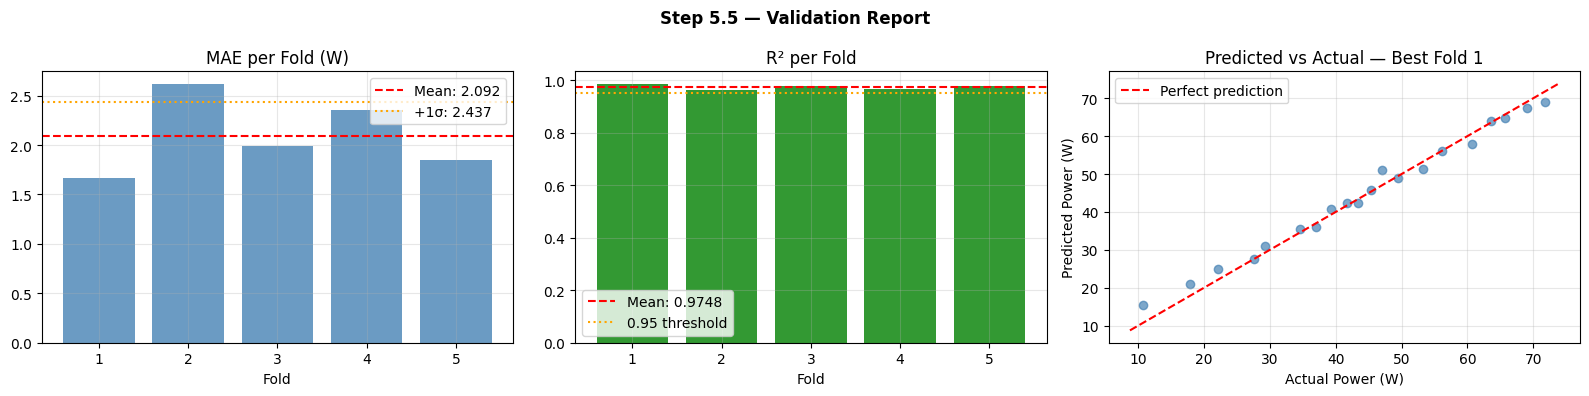


  Plot saved → validation_report.png


In [1404]:
# Validation => AI 

# ── 1. Per-Fold Table ─────────────────────────────────────────────────────
print("=" * 65)
print("  Step 5.5 — Validation Report")
print("=" * 65)
print(f"  {'Fold':>5} | {'MAE (W)':>10} | {'RMSE (W)':>10} | {'R²':>8} | {'Status':>10}")
print(f"  {'-'*55}")

mean_mae  = np.mean(fold_mae_list)
std_mae   = np.std(fold_mae_list)

for i, (mae, rmse, r2) in enumerate(zip(fold_mae_list, fold_rmse_list, fold_r2_list)):
    # Flag folds more than 1 std above mean MAE
    status = '⚠ unstable' if mae > mean_mae + std_mae else '✓ ok'
    print(f"  {i+1:>5} | {mae:>10.4f} | {rmse:>10.4f} | {r2:>8.4f} | {status:>10}")

# ── 2. Summary Statistics ─────────────────────────────────────────────────
print(f"\n  {'─'*55}")
print(f"  {'Mean':>5} | {mean_mae:>10.4f} | {np.mean(fold_rmse_list):>10.4f} | {np.mean(fold_r2_list):>8.4f}")
print(f"  {'Std':>5} | {std_mae:>10.4f} | {np.std(fold_rmse_list):>10.4f} | {np.std(fold_r2_list):>8.4f}")
print(f"  {'Min':>5} | {np.min(fold_mae_list):>10.4f} | {np.min(fold_rmse_list):>10.4f} | {np.min(fold_r2_list):>8.4f}")
print(f"  {'Max':>5} | {np.max(fold_mae_list):>10.4f} | {np.max(fold_rmse_list):>10.4f} | {np.max(fold_r2_list):>8.4f}")
print("=" * 65)

# ── 3. Consistency Check ──────────────────────────────────────────────────
print("\n  Consistency Check")
print("  " + "-" * 40)

cv_mae = std_mae / mean_mae   # coefficient of variation
if cv_mae < 0.1:
    print(f"  MAE CV : {cv_mae:.3f}  ✓ consistent across folds")
elif cv_mae < 0.2:
    print(f"  MAE CV : {cv_mae:.3f}  ⚠ moderate variance — check unstable folds")
else:
    print(f"  MAE CV : {cv_mae:.3f}  ✗ high variance — model unstable")

r2_min = np.min(fold_r2_list)
if r2_min > 0.95:
    print(f"  R² min : {r2_min:.4f}  ✓ all folds above 0.95")
elif r2_min > 0.90:
    print(f"  R² min : {r2_min:.4f}  ⚠ some folds below 0.95")
else:
    print(f"  R² min : {r2_min:.4f}  ✗ weak folds — consider tuning")

# ── 4. Residual Analysis — rerun best fold ────────────────────────────────
print("\n  Residual Analysis (best fold)")
print("  " + "-" * 40)

# Reload best model
best_model = Power(input_dim=x.shape[1]).to(device)
best_model.load_state_dict(best_fold_state)

# Rebuild val set for best fold
best_fold_idx = np.argmin(fold_mae_list)
_, val_idx    = fold_indices[best_fold_idx]

x_mean = best_fold_stats['x_mean']
x_std  = best_fold_stats['x_std']
y_mean = best_fold_stats['y_mean']
y_std  = best_fold_stats['y_std']

x_val_norm = (x[val_idx] - x_mean) / x_std
y_val_norm = (y[val_idx] - y_mean) / y_std
c_val      = c[val_idx]

val_ds     = Validation(x_val_norm, y_val_norm, c_val)
val_loader = torch.utils.data.DataLoader(val_ds, batch_size=batch_size, shuffle=False)

_, y_pred_norm, y_true_norm = evaluate(best_model, val_loader, device)

y_pred_w = (y_pred_norm * y_std + y_mean).numpy()
y_true_w = (y_true_norm * y_std + y_mean).numpy()
residuals = y_pred_w - y_true_w

print(f"  Residual mean  : {residuals.mean():>8.4f} W  (close to 0 = unbiased)")
print(f"  Residual std   : {residuals.std():>8.4f} W")
print(f"  Max overpredict: {residuals.max():>8.4f} W")
print(f"  Max underpredict:{residuals.min():>8.4f} W")

if abs(residuals.mean()) < 0.5:
    print(f"  Bias           : ✓ model is unbiased")
else:
    print(f"  Bias           : ⚠ systematic bias detected — check features")

# ── 5. Power Range Coverage ───────────────────────────────────────────────
print("\n  Power Range Coverage (best fold)")
print("  " + "-" * 40)

# Split into low / mid / high Power thirds
sorted_i  = np.argsort(y_true_w)
n         = len(y_true_w)
thirds    = n // 3

low_mae   = np.mean(np.abs(residuals[sorted_i[:thirds]]))
mid_mae   = np.mean(np.abs(residuals[sorted_i[thirds:2*thirds]]))
high_mae  = np.mean(np.abs(residuals[sorted_i[2*thirds:]]))

print(f"  Low  Power MAE : {low_mae:>8.4f} W  (y < {y_true_w[sorted_i[thirds-1]]:.1f} W)")
print(f"  Mid  Power MAE : {mid_mae:>8.4f} W")
print(f"  High Power MAE : {high_mae:>8.4f} W  (y > {y_true_w[sorted_i[2*thirds]]:.1f} W)")

worst = max(low_mae, mid_mae, high_mae)
if worst < 2 * np.mean([low_mae, mid_mae, high_mae]):
    print(f"  Coverage       : ✓ consistent across Power range")
else:
    print(f"  Coverage       : ⚠ model struggles at certain Power ranges")

# ── 6. Plots ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Step 5.5 — Validation Report', fontweight='bold')

folds_x = range(1, K + 1)

# MAE per fold
axes[0].bar(folds_x, fold_mae_list, color='steelblue', alpha=0.8)
axes[0].axhline(mean_mae, color='red', linestyle='--', label=f'Mean: {mean_mae:.3f}')
axes[0].axhline(mean_mae + std_mae, color='orange', linestyle=':', label=f'+1σ: {mean_mae+std_mae:.3f}')
axes[0].set_title('MAE per Fold (W)')
axes[0].set_xlabel('Fold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# R² per fold
axes[1].bar(folds_x, fold_r2_list, color='green', alpha=0.8)
axes[1].axhline(np.mean(fold_r2_list), color='red', linestyle='--',
                label=f'Mean: {np.mean(fold_r2_list):.4f}')
axes[1].axhline(0.95, color='orange', linestyle=':', label='0.95 threshold')
axes[1].set_title('R² per Fold')
axes[1].set_xlabel('Fold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Predicted vs Actual (best fold)
axes[2].scatter(y_true_w, y_pred_w, alpha=0.7, color='steelblue')
lims = [min(y_true_w.min(), y_pred_w.min()) - 2,
        max(y_true_w.max(), y_pred_w.max()) + 2]
axes[2].plot(lims, lims, 'r--', label='Perfect prediction')
axes[2].set_title(f'Predicted vs Actual — Best Fold {best_fold_idx+1}')
axes[2].set_xlabel('Actual Power (W)')
axes[2].set_ylabel('Predicted Power (W)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('validation_report.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n  Plot saved → validation_report.png")

In [1405]:
# ── Print learned weights ─────────────────────────────────────────────────
print("\n  Learned Weights — Best Fold Model")
print("=" * 65)

best_model = Power(input_dim=x.shape[1]).to(device)
best_model.load_state_dict(best_fold_state)

for name, param in best_model.named_parameters():
    print(f"\n  {name}")
    print(f"    shape : {list(param.shape)}")
    print(f"    mean  : {param.data.mean().item():>10.6f}")
    print(f"    std   : {param.data.std().item():>10.6f}")
    print(f"    min   : {param.data.min().item():>10.6f}")
    print(f"    max   : {param.data.max().item():>10.6f}")

print("=" * 65)

""""
block1  mean≈-0.009, std=0.124   ✓ centered around zero
block2  mean≈-0.001, std=0.101   ✓ centered around zero
block3  mean≈-0.002, std=0.073   ✓ getting smaller — expected
block4  mean≈-0.002, std=0.053   ✓ getting smaller — expected
block5  mean≈-0.007, std=0.073   ✓ normal
head    mean≈ 0.010, std=0.077   ✓ normal

"""


  Learned Weights — Best Fold Model

  block1.0.weight
    shape : [32, 22]
    mean  :  -0.008403
    std   :   0.123472
    min   :  -0.296568
    max   :   0.320926

  block1.0.bias
    shape : [32]
    mean  :  -0.000407
    std   :   0.127763
    min   :  -0.204508
    max   :   0.203859

  block1.1.weight
    shape : [32]
    mean  :   0.960372
    std   :   0.032233
    min   :   0.902842
    max   :   1.038386

  block1.1.bias
    shape : [32]
    mean  :  -0.019402
    std   :   0.035071
    min   :  -0.089729
    max   :   0.074547

  block2.0.weight
    shape : [64, 32]
    mean  :  -0.001591
    std   :   0.100191
    min   :  -0.228790
    max   :   0.234809

  block2.0.bias
    shape : [64]
    mean  :   0.003866
    std   :   0.090197
    min   :  -0.155476
    max   :   0.163633

  block2.1.weight
    shape : [64]
    mean  :   0.974309
    std   :   0.028043
    min   :   0.921880
    max   :   1.034644

  block2.1.bias
    shape : [64]
    mean  :   0.008873
    std 

'"\nblock1  mean≈-0.009, std=0.124   ✓ centered around zero\nblock2  mean≈-0.001, std=0.101   ✓ centered around zero\nblock3  mean≈-0.002, std=0.073   ✓ getting smaller — expected\nblock4  mean≈-0.002, std=0.053   ✓ getting smaller — expected\nblock5  mean≈-0.007, std=0.073   ✓ normal\nhead    mean≈ 0.010, std=0.077   ✓ normal\n\n'

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 6 — SAVE & INFERENCE
# ─────────────────────────────────────────────────────────────────────────────

# ── 6.1 Final Summary ─────────────────────────────────────────────────────────
print("=" * 60)
print("  Step 6 — Final Summary")
print("=" * 60)
print(f"  Architecture  : {x.shape[1]}→32→64→128→64→32→1")
print(f"  K-Folds       : {K}  (stratified)")
print(f"  Samples       : {len(x)} real")
print(f"  Features      : {x.shape[1]}")
print(f"  Target        : Power (W)")
print(f"  PINN checks   : {CHECK}")
print(f"  Lambda    : {LAMBDA}")
print(f"{'-'*60}")
print(f"  Mean MAE      : {np.mean(fold_mae_list):.4f} W  ±  {np.std(fold_mae_list):.4f}")
print(f"  Mean RMSE     : {np.mean(fold_rmse_list):.4f} W  ±  {np.std(fold_rmse_list):.4f}")
print(f"  Mean R²       : {np.mean(fold_r2_list):.4f}    ±  {np.std(fold_r2_list):.4f}")
print(f"  Best fold MAE : {best_fold_mae:.4f} W")
print("=" * 60)


# ── 6.2 Save — ONE save, flat keys ────────────────────────────────────────────
# Bug fixed: original had TWO torch.save calls — second overwrote first
# with nested keys (best_fold_state, best_fold_stats) that predict_power
# then tried to read, causing KeyError on 'input_dim'.
torch.save({
    'model_state_dict' : best_fold_state,            # flat key
    'x_mean'           : best_fold_stats['x_mean'],  # flat key
    'x_std'            : best_fold_stats['x_std'],
    'y_mean'           : best_fold_stats['y_mean'],
    'y_std'            : best_fold_stats['y_std'],
    'feature_cols'     : feature_cols,
    'input_dim'        : x.shape[1],
    'K'                : K,
    'fold_mae_list'    : fold_mae_list,
    'fold_r2_list'     : fold_r2_list,
}, 'power_model_best.pt')

print(f"\n  Saved → power_model_best.pt")


# ── 6.3 Inference ─────────────────────────────────────────────────────────────
def predict_power(feature_dict: dict) -> float:
    """
    Predict Power (W) for a single new sample.
    feature_dict : {col_name: raw_value} for all feature columns.
    Normalization is applied internally.
    """
    checkpoint = torch.load('power_model_best.pt', weights_only=False)

    net = Power(input_dim=checkpoint['input_dim'])
    net.load_state_dict(checkpoint['model_state_dict'])  # fixed: was 'best_fold_state'
    net.eval()

    cols   = checkpoint['feature_cols']
    x_mean = checkpoint['x_mean']   # fixed: was checkpoint['best_fold_stats']['x_mean']
    x_std  = checkpoint['x_std']
    y_mean = checkpoint['y_mean']
    y_std  = checkpoint['y_std']

    x_raw  = torch.tensor(
        [[feature_dict[c] for c in cols]], dtype=torch.float32
    )
    x_norm = (x_raw - x_mean) / x_std

    with torch.no_grad():
        pred_norm = net(x_norm)

    return (pred_norm * y_std + y_mean).item()


# ── 6.4 Inference examples ────────────────────────────────────────────────────
print(f"\n  Inference Examples — Real Samples")
print("=" * 60)
print(f"  {'Sample':>8} | {'Actual (W)':>12} | {'Predicted (W)':>14} | {'Error (W)':>10}")
print(f"  {'-'*52}")

test_indices = torch.randperm(len(x))[:5]

for i, idx in enumerate(test_indices):
    feature_dict = {col: x[idx, j].item() for j, col in enumerate(feature_cols)}
    actual       = y[idx].item()
    predicted    = predict_power(feature_dict)
    error        = predicted - actual
    print(f"  {i+1:>8} | {actual:>12.4f} | {predicted:>14.4f} | {error:>10.4f}")

print("=" * 60)
print("\n  ✓ Step 6 complete")


# ── 6.5 Results verdict ───────────────────────────────────────────────────────
# Compute from fold loop variables — no res dict needed
mae_arr       = np.array(fold_mae_list)
rmse_arr      = np.array(fold_rmse_list)
r2_arr        = np.array(fold_r2_list)
mae_mean      = float(mae_arr.mean())
mae_std       = float(mae_arr.std())
r2_mean       = float(r2_arr.mean())
mae_cv        = (mae_std / mae_mean) * 100

# Full cross-val predictions from Cell 14
y_pred_all    = np.concatenate(all_preds_global)
y_actual_all  = np.concatenate(all_actuals_global)
residuals     = y_pred_all - y_actual_all
bias          = float(residuals.mean())
pct_within_2w = float((np.abs(residuals) <= 2.0).mean() * 100)

low_thresh    = np.quantile(y_actual_all, 0.33)
low_mask      = y_actual_all <= low_thresh
low_mae_mean  = float(np.mean(np.abs(residuals[low_mask]))) if low_mask.sum() > 0 else float('inf')

MAE_THRESHOLD     = 1.5
LOW_MAE_THRESHOLD = 2.5
R2_THRESHOLD      = 0.975

print(f"\n{'═'*65}")
print(f"  Results")
print(f"{'═'*65}")

checks = [
    ("Mean MAE",     f"{mae_mean:.4f} W",        mae_mean      < MAE_THRESHOLD,     f"< {MAE_THRESHOLD} W"),
    ("Low MAE",      f"{low_mae_mean:.4f} W",     low_mae_mean  < LOW_MAE_THRESHOLD, f"< {LOW_MAE_THRESHOLD} W"),
    ("Mean R²",      f"{r2_mean:.4f}",            r2_mean       > R2_THRESHOLD,      f"> {R2_THRESHOLD}"),
    ("Bias",         f"{bias:+.4f} W",            abs(bias)     < 0.5,               "< ±0.5 W"),
    ("Consistency",  f"CV={mae_cv:.1f}%",         mae_cv        < 25,                "CV < 25%"),
    ("±2W coverage", f"{pct_within_2w:.1f}%",     pct_within_2w > 80,                "> 80%"),
]

all_pass = True
for name, value, passed, target in checks:
    icon = "✓" if passed else "✗"
    if not passed:
        all_pass = False
    print(f"  {icon}  {name:<16} {value:<12}  target {target}")

print(f"{'─'*65}")
if all_pass:
    print(f"  ✓ Model passes all checks — ready for deployment")
else:
    print(f"  ✗ Some checks failed — consider further tuning")
print(f"{'═'*65}")


  Step 6 — Final Summary
  Architecture  : 22→32→64→128→64→32→1
  K-Folds       : 5  (stratified)
  Samples       : 100 real
  Features      : 22
  Target        : Power (W)
  PINN checks   : ['F_cl', 'Torque', 'Power']
  Lambda PINN   : 0.1
------------------------------------------------------------
  Mean MAE      : 2.0925 W  ±  0.3442
  Mean RMSE     : 2.6259 W  ±  0.4060
  Mean R²       : 0.9748    ±  0.0080
  Best fold MAE : 1.6670 W

  Saved → power_model_best.pt

  Inference Examples — Real Samples
    Sample |   Actual (W) |  Predicted (W) |  Error (W)
  ----------------------------------------------------
         1 |      29.2052 |        30.9375 |     1.7323
         2 |      39.2286 |        40.8904 |     1.6618
         3 |      43.4536 |        42.3981 |    -1.0556
         4 |      38.4111 |        39.0658 |     0.6546
         5 |      71.7917 |        70.3392 |    -1.4525

  ✓ Step 6 complete

═════════════════════════════════════════════════════════════════
  Results

In [1407]:
# Run after the K-fold loop
print(f"{'Fold':>5} | {'MAE':>8} | {'Low MAE':>9} | {'Bias':>8} | {'±2W%':>7}")
print("-" * 45)
for i, (mae, rmse, r2) in enumerate(zip(fold_mae_list, fold_rmse_list, fold_r2_list)):
    preds   = all_preds_global[i]
    actuals = all_actuals_global[i]
    resid   = preds - actuals
    low_t   = np.quantile(actuals, 0.33)
    low_m   = actuals <= low_t
    low_mae = np.mean(np.abs(resid[low_m])) if low_m.sum() > 0 else float('nan')
    bias    = resid.mean()
    p2w     = (np.abs(resid) <= 2.0).mean() * 100
    print(f"{i+1:>5} | {mae:>8.4f} | {low_mae:>9.4f} | {bias:>+8.4f} | {p2w:>6.1f}%")

 Fold |      MAE |   Low MAE |     Bias |    ±2W%
---------------------------------------------
    1 |   1.6670 |    2.0610 |  +0.4195 |   70.0%
    2 |   2.6146 |    4.1786 |  +1.6760 |   40.0%
    3 |   1.9865 |    2.9465 |  +0.8080 |   50.0%
    4 |   2.3494 |    3.2432 |  +0.6620 |   55.0%
    5 |   1.8448 |    1.9995 |  -0.1120 |   55.0%
